# Proyecto Final - Machine Learning

## Predicción del consumo eléctrico de electrodomésticos

### Objetivo

El objetivo de este proyecto es desarrollar y comparar diferentes modelos de Machine Learning para predecir el consumo energético de los electrodomésticos de una vivienda utilizando variables ambientales y temporales.

### Tipo de problema

Aprendizaje supervisado - Regresión

## 1. Importación de librerías

Para el desarrollo del proyecto se utilizarán librerías de Python para el manejo de datos, cálculos numéricos, visualización y Machine Learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Carga del dataset

Se carga el conjunto de datos que contiene información sobre el consumo energético de una vivienda y diferentes variables ambientales.

In [3]:
df = pd.read_csv('energydata_complete.csv')

In [4]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 3. Exploración inicial de los datos

Antes de construir los modelos se realiza una exploración inicial para conocer el tamaño del dataset, los tipos de variables y verificar la existencia de valores faltantes.

In [5]:
df.shape

(19735, 29)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [7]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

### Conclusiones de la exploración inicial

El dataset contiene 19.735 registros y 29 columnas. La mayoría de las variables son numéricas y representan mediciones de temperatura, humedad y condiciones ambientales.

La variable `date` se encuentra almacenada como texto, por lo que posteriormente será necesario convertirla a formato de fecha y hora.

También se verificó la existencia de valores faltantes y se encontró que ninguna de las variables presenta datos nulos, por lo que no será necesario realizar imputación de valores faltantes.

## 4. Análisis estadístico de los datos

Se analizan las principales estadísticas descriptivas del dataset para conocer el comportamiento de las variables numéricas.

In [8]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [11]:
df.duplicated().sum()

np.int64(0)

### Interpretación de las estadísticas

La variable objetivo `Appliances`, que representa el consumo energético de los electrodomésticos, presenta un consumo promedio aproximado de 97.69 Wh.

La mediana del consumo es de 60 Wh, mientras que el valor máximo alcanza los 1080 Wh. La diferencia entre el promedio y la mediana indica que existen algunos registros con consumos considerablemente más altos que la mayoría de las observaciones.

También se verificaron registros duplicados y no se encontraron filas repetidas en el dataset.

## 5. Análisis exploratorio y visualización

Se realizan diferentes visualizaciones para comprender mejor el comportamiento del consumo energético y su relación con otras variables del dataset.

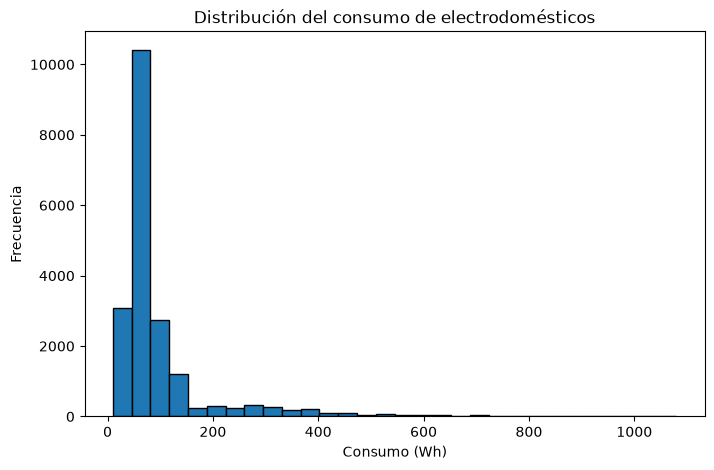

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df['Appliances'], bins=30, edgecolor='black')

plt.title('Distribución del consumo de electrodomésticos')
plt.xlabel('Consumo (Wh)')
plt.ylabel('Frecuencia')

plt.show()

### Interpretación

La distribución del consumo de los electrodomésticos está sesgada hacia la derecha. La mayoría de los registros presentan consumos relativamente bajos, mientras que existen algunos valores de consumo considerablemente más altos.

Esto explica por qué el valor promedio del consumo es superior a la mediana.

C:\Users\Ana Maria Lopez\AppData\Local\Temp\ipykernel_6572\2640948132.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['Appliances'], vert=False)


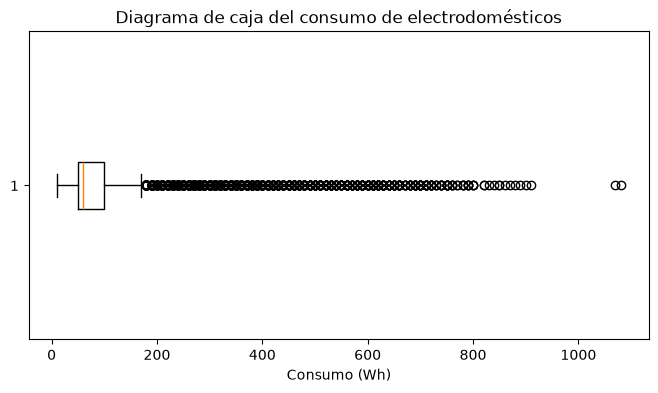

In [13]:
plt.figure(figsize=(8, 4))

plt.boxplot(df['Appliances'], vert=False)

plt.title('Diagrama de caja del consumo de electrodomésticos')
plt.xlabel('Consumo (Wh)')

plt.show()

## 6. Preparación de la fecha y hora

El dataset contiene una columna llamada `date` que indica el momento en el que se realizó cada medición. Esta variable se convierte a formato de fecha y hora para poder analizar el comportamiento del consumo a lo largo del tiempo.

In [14]:
df['date'] = pd.to_datetime(df['date'])

In [15]:
df['date'].dtype

dtype('<M8[us]')

## 7. Periodo de tiempo del dataset

Se analiza el intervalo de tiempo cubierto por el dataset, identificando la primera y la última medición registrada.

También se verifica la frecuencia con la que se realizaron las mediciones.

In [16]:
print("Primera medición:", df['date'].min())
print("Última medición:", df['date'].max())

Primera medición: 2016-01-11 17:00:00
Última medición: 2016-05-27 18:00:00


In [17]:
df['date'].max() - df['date'].min()

Timedelta('137 days 01:00:00')

## 8. Creación de variables temporales

A partir de la columna `date` se extraen nuevas variables relacionadas con el tiempo.

Se crea la variable `hour`, que representa la hora del día en la que se realizó cada medición, y la variable `day_of_week`, que representa el día de la semana.

Estas variables permitirán analizar si el consumo energético cambia dependiendo del momento en el que se realiza la medición.

In [25]:
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek

In [26]:
df[['date', 'hour', 'day_of_week']].head(10)

,date,hour,day_of_week
0,2016-01-11 17:00:00,17,0
1,2016-01-11 17:10:00,17,0
2,2016-01-11 17:20:00,17,0
3,2016-01-11 17:30:00,17,0
4,2016-01-11 17:40:00,17,0
5,2016-01-11 17:50:00,17,0
6,2016-01-11 18:00:00,18,0
7,2016-01-11 18:10:00,18,0
8,2016-01-11 18:20:00,18,0
9,2016-01-11 18:30:00,18,0


## 9. Consumo promedio según la hora del día

Se agrupan las mediciones según la hora del día y se calcula el consumo promedio de los electrodomésticos.

Este análisis permite identificar si existen horas en las que el consumo energético tiende a ser mayor o menor.

In [27]:
consumo_por_hora = df.groupby('hour')['Appliances'].mean()

consumo_por_hora

hour
0      52.785888
1      51.326034
2      49.075426
3      48.236010
4      49.355231
5      52.737226
6      57.712895
7      78.649635
8     106.143552
9     112.785888
10    125.377129
11    133.126521
12    123.637470
13    124.744526
14    108.284672
15    105.827251
16    119.902676
17    161.352657
18    190.364520
19    143.065693
20    126.982968
21     96.496350
22     69.148418
23     56.982968
Name: Appliances, dtype: float64

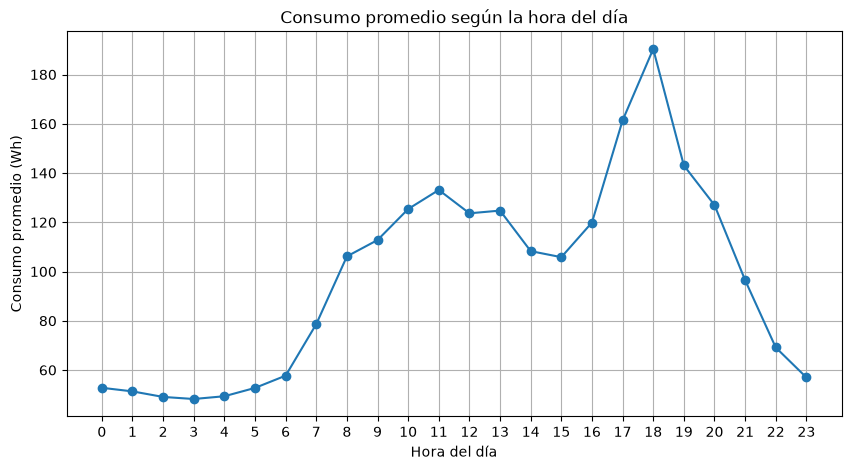

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    consumo_por_hora.index,
    consumo_por_hora.values,
    marker='o'
)

plt.title('Consumo promedio según la hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Consumo promedio (Wh)')
plt.xticks(range(0, 24))
plt.grid(True)

plt.show()

### Interpretación

El consumo energético presenta diferencias claras dependiendo de la hora del día.

Durante la madrugada se observan los niveles promedio de consumo más bajos. A partir de las primeras horas de la mañana el consumo comienza a aumentar y presenta su valor promedio más alto alrededor de las 18:00.

Después de este punto, el consumo disminuye progresivamente durante la noche.

Este comportamiento indica que la hora del día puede ser una variable relevante para los modelos de Machine Learning.

## 10. Selección de variables para el modelado

Para construir los modelos de Machine Learning se seleccionan variables relacionadas con la temperatura, la humedad, las condiciones exteriores y el momento del día.

La variable objetivo será `Appliances`, ya que representa el consumo energético que se desea predecir.

Las variables `rv1` y `rv2` no serán utilizadas porque corresponden a variables aleatorias incluidas en el dataset y no representan características reales relacionadas con el consumo.

In [29]:
variables = [
    'hour',
    'day_of_week',
    'T1',
    'RH_1',
    'T2',
    'RH_2',
    'T3',
    'RH_3',
    'T_out',
    'RH_out',
    'Windspeed',
    'Press_mm_hg'
]

X = df[variables]

y = df['Appliances']

In [30]:
X.head()

,hour,day_of_week,T1,RH_1,T2,RH_2,T3,RH_3,T_out,RH_out,Windspeed,Press_mm_hg
0,17,0,19.89,47.596667,19.2,44.790000,19.79,44.730000,6.600000,92.0,7.000000,733.5
1,17,0,19.89,46.693333,19.2,44.722500,19.79,44.790000,6.483333,92.0,6.666667,733.6
2,17,0,19.89,46.300000,19.2,44.626667,19.79,44.933333,6.366667,92.0,6.333333,733.7
3,17,0,19.89,46.066667,19.2,44.590000,19.79,45.000000,6.250000,92.0,6.000000,733.8
4,17,0,19.89,46.333333,19.2,44.530000,19.79,45.000000,6.133333,92.0,5.666667,733.9


In [31]:
y.head()

0    60
1    60
2    50
3    50
4    60
Name: Appliances, dtype: int64

Y finalmente ejecuta:

In [57]:
print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (19735, 12)
Tamaño de y: (19735,)


## 11. División de los datos en entrenamiento y prueba

Para evaluar correctamente los modelos de Machine Learning, los datos se dividen en dos conjuntos.

El conjunto de entrenamiento contiene el 80% de los registros y será utilizado para que los modelos aprendan los patrones existentes en los datos.

El conjunto de prueba contiene el 20% restante y permitirá evaluar el comportamiento de los modelos utilizando observaciones que no fueron utilizadas durante el entrenamiento.

Debido a que las mediciones están organizadas cronológicamente, se mantiene el orden temporal de los registros durante la división.

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

In [34]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (15788, 12)
Datos de prueba: (3947, 12)


In [58]:
print("y entrenamiento:", y_train.shape)
print("y prueba:", y_test.shape)

y entrenamiento: (15788,)
y prueba: (3947,)


## 12. Métricas de evaluación

Para determinar qué modelo realiza mejores predicciones se utilizarán tres métricas:

- **MAE (Mean Absolute Error):** representa el error promedio de las predicciones.
- **RMSE (Root Mean Squared Error):** también mide el error, pero penaliza más los errores grandes.
- **R² (Coeficiente de determinación):** indica qué tan bien logra el modelo explicar la variabilidad del consumo.

En MAE y RMSE, valores más bajos representan mejores resultados.

En R², valores más cercanos a 1 representan un mejor desempeño.

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
def evaluar_modelo(nombre, valores_reales, predicciones):
    
    mae = mean_absolute_error(valores_reales, predicciones)
    
    rmse = np.sqrt(
        mean_squared_error(valores_reales, predicciones)
    )
    
    r2 = r2_score(valores_reales, predicciones)
    
    print(nombre)
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²:", round(r2, 3))
    
    return mae, rmse, r2

## 13. Modelo 1 - Regresión Lineal

El primer modelo utilizado es la Regresión Lineal.

Este algoritmo intenta encontrar relaciones lineales entre las variables utilizadas como entrada y el consumo energético.

Se utiliza como un modelo inicial sencillo que servirá como referencia para comparar posteriormente modelos más complejos.

In [37]:
from sklearn.linear_model import LinearRegression

Creamos el modelo:

In [38]:
modelo_lineal = LinearRegression()

Lo entrenamos:

In [39]:
modelo_lineal.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 3.01, 0.12,-1.84,...,-0.29, 0.84, 0.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['hour','day_of_week','T1',...,'RH_out','Windspeed','Press_mm_hg']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-105.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


Después hacemos predicciones:

In [40]:
pred_lineal = modelo_lineal.predict(X_test)

Ahora evaluamos:

In [41]:
mae_lineal, rmse_lineal, r2_lineal = evaluar_modelo(
    "Regresión Lineal",
    y_test,
    pred_lineal
)

Regresión Lineal
MAE: 62.42
RMSE: 89.45
R²: 0.035


### Comparación entre valores reales y predicciones

Para analizar visualmente el comportamiento de la Regresión Lineal, se comparan los valores reales de consumo con los valores predichos por el modelo.

Si el modelo realiza buenas predicciones, los valores predichos deberían encontrarse próximos a los valores reales.

In [59]:
comparacion_lineal = pd.DataFrame({
    'Consumo Real': y_test.values,
    'Predicción': pred_lineal
})

comparacion_lineal.head(10)

,Consumo Real,Predicción
0,370,86.445734
1,590,85.565595
2,320,88.215060
3,310,88.000565
4,260,93.099655
5,190,97.527163
6,150,97.276132
7,130,99.671987
8,290,98.283668
9,490,96.741707


Gráfico Real vs Predicción

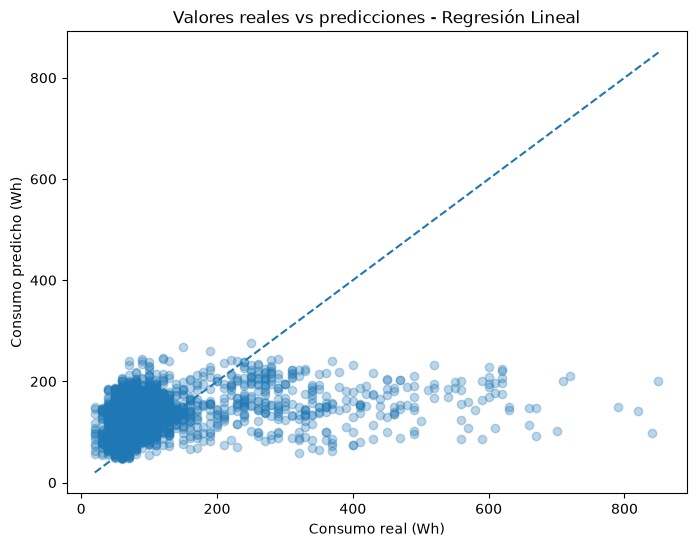

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    pred_lineal,
    alpha=0.3
)

limite_min = min(y_test.min(), pred_lineal.min())
limite_max = max(y_test.max(), pred_lineal.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle='--'
)

plt.title('Valores reales vs predicciones - Regresión Lineal')
plt.xlabel('Consumo real (Wh)')
plt.ylabel('Consumo predicho (Wh)')

plt.show()

### Interpretación del modelo

La gráfica muestra que las predicciones de la Regresión Lineal presentan una dispersión considerable respecto a la línea de predicción ideal.

El modelo presenta un mejor comportamiento para consumos bajos y medios, pero tiende a subestimar los valores de consumo elevados.

Esto coincide con el bajo valor de R² obtenido y sugiere que las relaciones entre las variables y el consumo energético no pueden representarse adecuadamente mediante un modelo lineal simple.

Por esta razón, se evaluarán modelos no lineales como el Árbol de Decisión y Random Forest.

## 14. Modelo 2 - Árbol de Decisión

El segundo modelo utilizado es un Árbol de Decisión para regresión.

Este algoritmo divide los datos mediante diferentes condiciones relacionadas con las variables de entrada.

A diferencia de la Regresión Lineal, el Árbol de Decisión puede identificar relaciones no lineales entre las características y el consumo energético.

In [42]:
from sklearn.tree import DecisionTreeRegressor

Creamos el modelo:

In [43]:
modelo_arbol = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

Entrenamos:

In [44]:
modelo_arbol.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

Predecimos:

In [45]:
pred_arbol = modelo_arbol.predict(X_test)

Evaluamos:

In [46]:
mae_arbol, rmse_arbol, r2_arbol = evaluar_modelo(
    "Árbol de Decisión",
    y_test,
    pred_arbol
)

Árbol de Decisión
MAE: 206.17
RMSE: 315.49
R²: -11.01


### Comparación entre valores reales y predicciones

Se comparan algunos valores reales de consumo con las predicciones obtenidas mediante el Árbol de Decisión.

Esta comparación permite observar directamente qué tan cerca se encuentran las estimaciones del modelo de los valores registrados realmente.

In [62]:
comparacion_arbol = pd.DataFrame({
    'Consumo Real': y_test.values,
    'Predicción Árbol': pred_arbol
})

comparacion_arbol.head(10)

,Consumo Real,Predicción Árbol
0,370,82.442922
1,590,82.442922
2,320,82.442922
3,310,82.442922
4,260,82.442922
5,190,82.442922
6,150,82.442922
7,130,82.442922
8,290,82.442922
9,490,82.442922


Gráfico real vs predicción

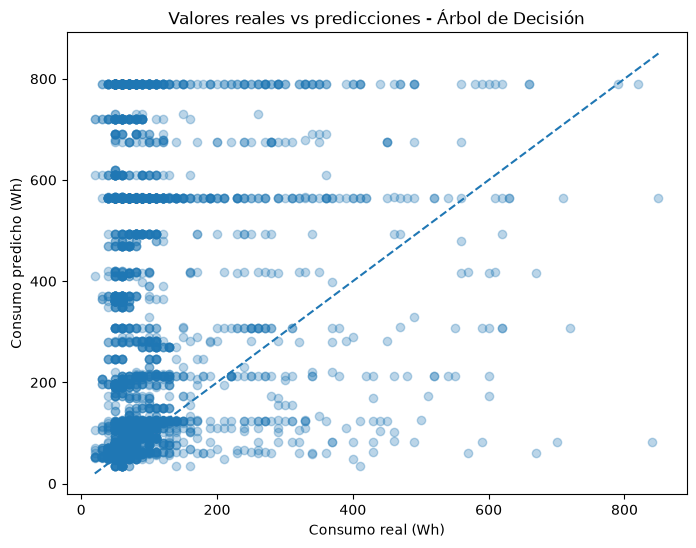

In [63]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    pred_arbol,
    alpha=0.3
)

limite_min = min(y_test.min(), pred_arbol.min())
limite_max = max(y_test.max(), pred_arbol.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle='--'
)

plt.title('Valores reales vs predicciones - Árbol de Decisión')
plt.xlabel('Consumo real (Wh)')
plt.ylabel('Consumo predicho (Wh)')

plt.show()

### Interpretación del modelo

El Árbol de Decisión obtuvo un MAE de 206.17 Wh, un RMSE de 315.49 Wh y un R² de -11.01.

Estos resultados muestran un rendimiento considerablemente inferior al obtenido mediante la Regresión Lineal.

El valor negativo de R² indica que el modelo no logra generalizar adecuadamente sobre el conjunto de prueba.

En la gráfica de valores reales frente a predicciones se observa una alta dispersión respecto a la línea ideal y varias predicciones repetidas para consumos reales muy diferentes.

Una posible explicación es que los datos fueron divididos respetando su orden cronológico. Debido a esto, el conjunto de prueba corresponde a un periodo posterior al utilizado durante el entrenamiento, y el Árbol de Decisión presenta dificultades para generalizar ante condiciones diferentes a las observadas previamente.

## 15. Modelo 3 - Random Forest

El tercer modelo utilizado es Random Forest Regressor.

Random Forest construye múltiples árboles de decisión y combina las predicciones realizadas por ellos.

Al utilizar varios árboles en lugar de depender de uno solo, el modelo puede obtener predicciones más robustas y reducir algunos errores producidos por un árbol individual.

In [47]:
from sklearn.ensemble import RandomForestRegressor

Creamos:

In [48]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

Entrenamos:

In [49]:
modelo_rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [50]:
pred_rf = modelo_rf.predict(X_test)

Y evaluamos:

In [51]:
mae_rf, rmse_rf, r2_rf = evaluar_modelo(
    "Random Forest",
    y_test,
    pred_rf
)

Random Forest
MAE: 131.21
RMSE: 169.26
R²: -2.456


### Comparación entre valores reales y predicciones

Se comparan algunos valores reales de consumo con las predicciones realizadas por Random Forest.

Esta comparación permite observar directamente qué tan cercanas se encuentran las estimaciones del modelo de los valores reales registrados.

In [64]:
comparacion_rf = pd.DataFrame({
    'Consumo Real': y_test.values,
    'Predicción Random Forest': pred_rf
})

comparacion_rf.head(10)

,Consumo Real,Predicción Random Forest
0,370,144.826285
1,590,132.753731
2,320,133.022955
3,310,133.825697
4,260,132.844515
5,190,135.512751
6,150,130.602415
7,130,126.403626
8,290,127.684798
9,490,127.873952


Gráfico real vs predicción

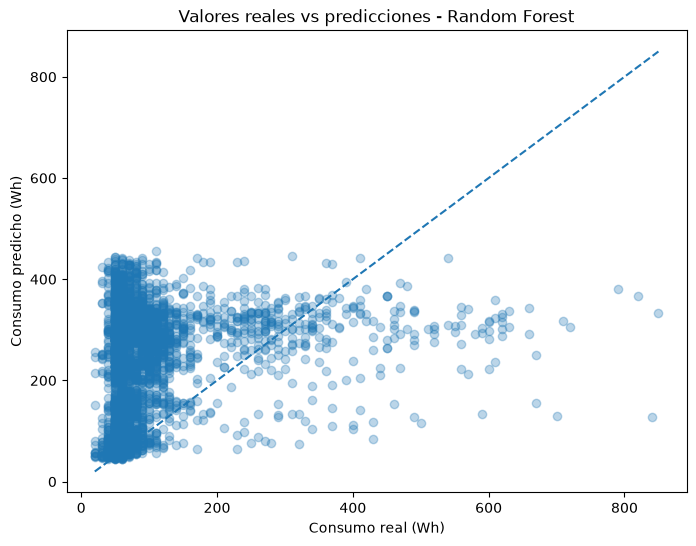

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    pred_rf,
    alpha=0.3
)

limite_min = min(y_test.min(), pred_rf.min())
limite_max = max(y_test.max(), pred_rf.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle='--'
)

plt.title('Valores reales vs predicciones - Random Forest')
plt.xlabel('Consumo real (Wh)')
plt.ylabel('Consumo predicho (Wh)')

plt.show()

### Interpretación del modelo

Random Forest obtuvo un MAE de 131.21 Wh, un RMSE de 169.26 Wh y un R² de -2.456.

El modelo presentó un mejor rendimiento que el Árbol de Decisión, reduciendo considerablemente tanto el MAE como el RMSE. Sin embargo, sus resultados fueron inferiores a los obtenidos mediante la Regresión Lineal.

El valor negativo de R² indica que Random Forest todavía presenta dificultades para generalizar sobre el conjunto de prueba.

En la gráfica de valores reales frente a predicciones se observa que existen diferencias importantes entre las estimaciones y los consumos reales, especialmente para algunos valores elevados.

Aunque la combinación de múltiples árboles mejoró los resultados respecto al uso de un único Árbol de Decisión, no fue suficiente para superar el rendimiento de la Regresión Lineal en este conjunto de prueba.

## 16. Comparación de los modelos

Después de entrenar los tres algoritmos, se comparan sus resultados utilizando las métricas MAE, RMSE y R².

Para MAE y RMSE, un valor menor representa un mejor rendimiento. Para R², un valor mayor indica una mejor capacidad del modelo para explicar la variabilidad observada en el consumo energético.

Esta comparación permitirá determinar cuál de los tres modelos presenta el mejor desempeño sobre el conjunto de prueba.

In [52]:
resultados = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal',
        'Árbol de Decisión',
        'Random Forest'
    ],
    'MAE': [
        mae_lineal,
        mae_arbol,
        mae_rf
    ],
    'RMSE': [
        rmse_lineal,
        rmse_arbol,
        rmse_rf
    ],
    'R2': [
        r2_lineal,
        r2_arbol,
        r2_rf
    ]
})

resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,62.421349,89.452653,0.034536
1,Árbol de Decisión,206.173797,315.492224,-11.009553
2,Random Forest,131.208534,169.255409,-2.456485


## 17. Comparación del error absoluto medio

Se compara visualmente el MAE obtenido por cada algoritmo.

Como el MAE representa el error promedio de las predicciones, el modelo con la barra más baja presenta un menor error promedio.

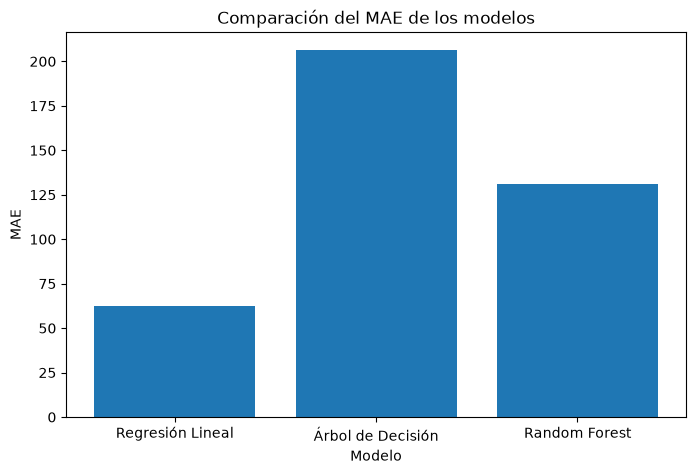

In [53]:
plt.figure(figsize=(8, 5))

plt.bar(
    resultados['Modelo'],
    resultados['MAE']
)

plt.title('Comparación del MAE de los modelos')
plt.xlabel('Modelo')
plt.ylabel('MAE')

plt.show()

### Comparación del RMSE

Se compara el RMSE de los tres modelos. Esta métrica penaliza con mayor intensidad los errores grandes.

Un menor valor de RMSE indica un mejor desempeño.

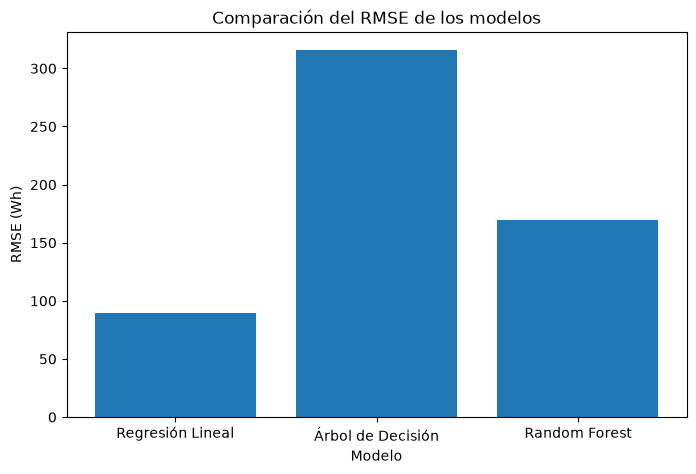

In [66]:
plt.figure(figsize=(8, 5))

plt.bar(
    resultados['Modelo'],
    resultados['RMSE']
)

plt.title('Comparación del RMSE de los modelos')
plt.xlabel('Modelo')
plt.ylabel('RMSE (Wh)')

plt.show()

### Comparación del coeficiente R²

Se compara el coeficiente de determinación R² obtenido por cada modelo.

A diferencia de MAE y RMSE, un valor más alto de R² representa un mejor rendimiento. Un valor cercano a 1 indica una mayor capacidad para explicar la variabilidad del consumo, mientras que valores negativos indican un rendimiento deficiente sobre el conjunto de prueba.

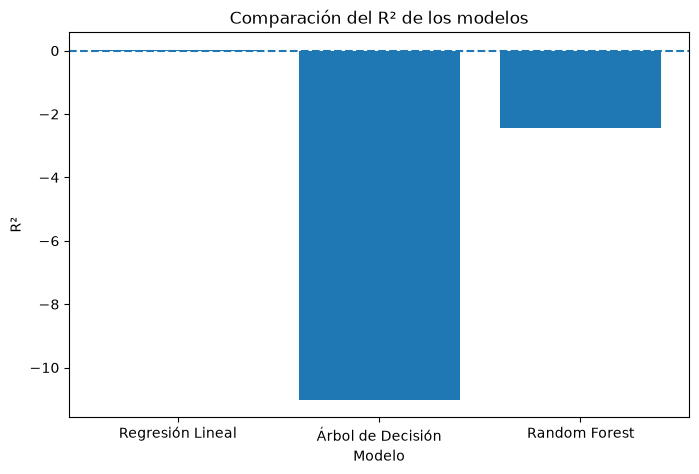

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    resultados['Modelo'],
    resultados['R2']
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Comparación del R² de los modelos')
plt.xlabel('Modelo')
plt.ylabel('R²')

plt.show()

### Interpretación del R²

La Regresión Lineal presentó el mayor valor de R², con aproximadamente 0.035.

Random Forest obtuvo un R² de -2.456 y el Árbol de Decisión un valor de -11.01.

Los valores negativos obtenidos por los modelos basados en árboles indican dificultades para generalizar sobre el periodo utilizado como conjunto de prueba.

Aunque la Regresión Lineal obtuvo el mejor R² de los tres modelos, su valor sigue siendo bajo, lo que indica que existe una parte importante del comportamiento del consumo que no logra ser explicada mediante las variables y modelos utilizados.

## 18. Comparación entre valores reales y predicciones

Después de comparar los tres modelos, la Regresión Lineal presentó el mejor rendimiento sobre el conjunto de prueba según las métricas MAE, RMSE y R².

Para analizar de forma más detallada su comportamiento, se comparan los valores reales de consumo con los valores predichos por este modelo.

Debido a que el conjunto de prueba contiene 3.947 observaciones, se muestra una parte de los registros para facilitar la visualización de las diferencias entre los valores reales y las predicciones.

In [68]:
comparacion_final = pd.DataFrame({
    'Consumo Real': y_test.values,
    'Predicción': pred_lineal
})

comparacion_final['Error Absoluto'] = abs(
    comparacion_final['Consumo Real'] - comparacion_final['Predicción']
)

comparacion_final.head(20)

,Consumo Real,Predicción,Error Absoluto
0,370,86.445734,283.554266
1,590,85.565595,504.434405
2,320,88.215060,231.784940
3,310,88.000565,221.999435
4,260,93.099655,166.900345
5,190,97.527163,92.472837
6,150,97.276132,52.723868
7,130,99.671987,30.328013
8,290,98.283668,191.716332
9,490,96.741707,393.258293


### Comparación directa

La tabla permite observar, para cada medición, el consumo registrado realmente, la predicción realizada por el modelo y la diferencia absoluta entre ambos valores.

Un error absoluto pequeño indica que la predicción se encuentra cerca del consumo real, mientras que un valor elevado representa una predicción menos precisa.

Gráfico

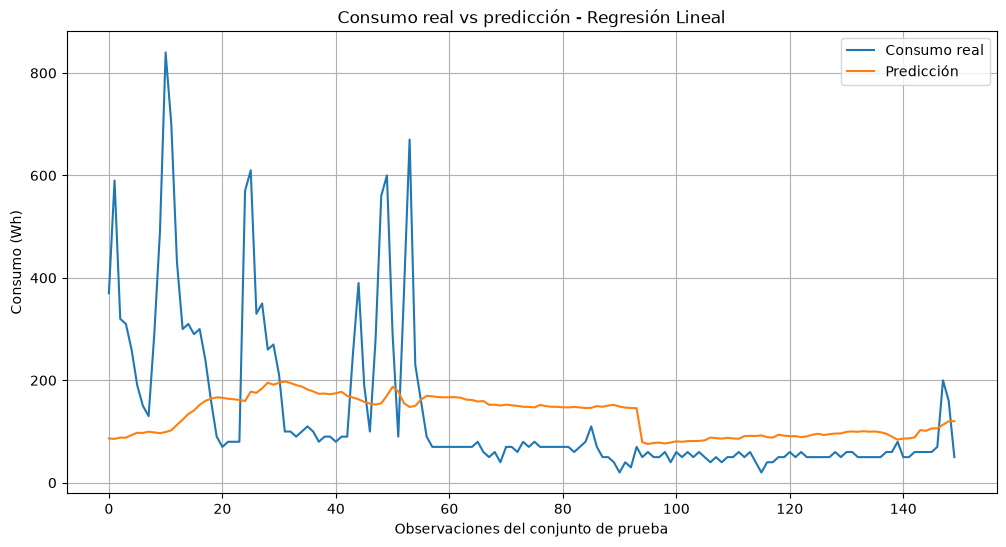

In [69]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:150],
    label='Consumo real'
)

plt.plot(
    pred_lineal[:150],
    label='Predicción'
)

plt.title('Consumo real vs predicción - Regresión Lineal')
plt.xlabel('Observaciones del conjunto de prueba')
plt.ylabel('Consumo (Wh)')

plt.legend()
plt.grid(True)

plt.show()

In [70]:
comparacion_final.sort_values(
    by='Error Absoluto',
    ascending=False
).head(10)

,Consumo Real,Predicción,Error Absoluto
10,840,99.032079,740.967921
3753,820,140.759128,679.240872
3794,850,200.106879,649.893121
3032,790,148.466243,641.533757
11,700,102.428124,597.571876
859,670,91.819577,578.180423
1870,660,113.526387,546.473613
53,670,147.955079,522.044921
3897,660,147.149925,512.850075
3042,720,210.561757,509.438243


### Interpretación

La comparación entre los valores reales y las predicciones muestra que la Regresión Lineal logra aproximarse a algunos niveles de consumo, pero presenta dificultades para seguir cambios bruscos y valores elevados.

En diferentes observaciones se aprecia una separación considerable entre el consumo real y el valor estimado por el modelo.

Este comportamiento coincide con las métricas obtenidas anteriormente. Aunque la Regresión Lineal presentó el mejor rendimiento entre los tres algoritmos evaluados, su R² de 0.035 indica que todavía tiene una capacidad limitada para explicar la variabilidad del consumo energético.

Por lo tanto, el modelo puede utilizarse como referencia dentro de este análisis, pero sus predicciones no deben considerarse altamente precisas.

## 19. Importancia de las variables

Además de realizar predicciones, Random Forest permite estimar la importancia relativa de las variables utilizadas durante el entrenamiento.

Este análisis ayuda a identificar cuáles características tuvieron mayor influencia en las decisiones del modelo.

Aunque Random Forest no obtuvo el mejor rendimiento general, el análisis de importancia de variables permite comprender mejor qué información fue utilizada con mayor frecuencia para estimar el consumo energético.

In [55]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by='Importancia',
    ascending=False
)

importancias

,Variable,Importancia
0,hour,0.201860
6,T3,0.109330
7,RH_3,0.096466
11,Press_mm_hg,0.094389
5,RH_2,0.089910
8,T_out,0.089511
9,RH_out,0.070397
3,RH_1,0.063524
4,T2,0.059631
2,T1,0.051801


Gráfico:

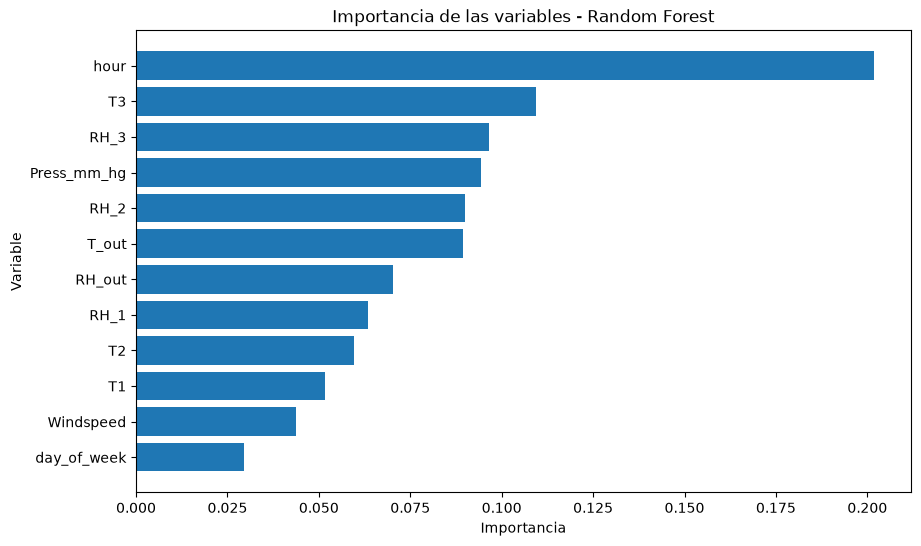

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    importancias['Variable'],
    importancias['Importancia']
)

plt.title('Importancia de las variables - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')

plt.gca().invert_yaxis()

plt.show()

In [71]:
importancias['Importancia'].sum()

np.float64(1.0)

### Interpretación de la importancia de las variables

El análisis de importancia de características muestra que la variable `hour` fue la más relevante para Random Forest, con aproximadamente un 20.2% de importancia relativa.

Este resultado es coherente con el análisis exploratorio realizado anteriormente, donde se observó que el consumo energético presenta diferencias importantes dependiendo de la hora del día.

Después de la hora, las variables con mayor importancia fueron `T3`, `RH_3`, `Press_mm_hg`, `RH_2` y `T_out`, relacionadas principalmente con condiciones de temperatura, humedad y ambiente.

La variable `day_of_week` presentó la menor importancia dentro del modelo.

Las importancias representan la relevancia relativa de cada variable dentro de Random Forest y no deben interpretarse como relaciones de causa y efecto.

## 20. Conclusiones

En este proyecto se aplicaron técnicas de Machine Learning para predecir el consumo energético de los electrodomésticos de una vivienda a partir de variables temporales y ambientales.

Inicialmente se realizó una exploración del conjunto de datos, compuesto por 19.735 registros. Se verificó que las mediciones fueron realizadas cada 10 minutos, que no existían valores faltantes ni registros duplicados y que la variable objetivo `Appliances` presentaba una distribución sesgada hacia la derecha, con la mayoría de los consumos concentrados en valores relativamente bajos y algunos periodos de consumo elevado.

El análisis temporal mostró que el consumo energético presenta diferencias importantes dependiendo de la hora del día. Durante la madrugada se observaron niveles de consumo promedio más bajos, mientras que el mayor consumo promedio se presentó aproximadamente alrededor de las 18:00. Por esta razón, la hora fue incorporada como una de las variables utilizadas para construir los modelos.

Posteriormente se entrenaron y evaluaron tres modelos de regresión: Regresión Lineal, Árbol de Decisión y Random Forest. Los modelos fueron evaluados utilizando MAE, RMSE y R².

- La Regresión Lineal obtuvo un MAE de 62.42 Wh, un RMSE de 89.45 Wh y un R² de 0.035. 
- El Árbol de Decisión obtuvo un MAE de 206.17 Wh, un RMSE de 315.49 Wh y un R² de -11.01. 
- Random Forest presentó un MAE de 131.21 Wh, un RMSE de 169.26 Wh y un R² de -2.456.

De los tres modelos evaluados, la Regresión Lineal presentó el mejor rendimiento sobre el conjunto de prueba, ya que obtuvo los menores valores de MAE y RMSE y el mayor valor de R².

Sin embargo, el R² obtenido por la Regresión Lineal sigue siendo bajo, por lo que el modelo tiene una capacidad limitada para explicar la variabilidad del consumo energético. Esto también pudo observarse en la comparación entre los valores reales y las predicciones, especialmente en los periodos donde se presentaron consumos elevados.

Los modelos basados en árboles mostraron mayores dificultades para generalizar sobre el conjunto de prueba. Una posible explicación es que la división entre entrenamiento y prueba se realizó respetando el orden cronológico de los datos, utilizando un periodo anterior para entrenar y un periodo posterior para evaluar los modelos.

El análisis de importancia de variables de Random Forest mostró que `hour` fue la característica con mayor importancia relativa, con aproximadamente un 20.2%. También tuvieron relevancia variables relacionadas con temperatura, humedad y condiciones ambientales. Este resultado es coherente con el análisis exploratorio, donde se observó que el consumo cambia considerablemente dependiendo de la hora del día.

En conclusión, la Regresión Lineal fue el modelo más adecuado entre los tres algoritmos evaluados bajo las condiciones de este experimento. No obstante, los resultados indican que todavía existe margen de mejora.
